# Q2 : Leaky Integrate and Fire (LIF) Model

Resistance $R$ = $40 M \Omega = 40 \times 10^6 \Omega$ </br>
Capacitance $C$ = $1 nF = 10^{-9} F$ </br>
Resting potential $u_{rest} = -65mV = -65 \times 10^{-3} V$ </br>
Current $I(t) = I_0\sin(2\pi ft)$ where $I_0 = 0.25nA = 0.25 \times 10^{-9}A$

Now, from the simplified equation,
$$
\tau \frac{du(t)}{dt} = - \left(u(t) - u_{rest} \right) + \frac{I(t)}{g_L}
$$
where, </br>
Characterstic constant $\tau = RC = 40 ms = 4 \times 10^{-2}s$ </br>
Membrane conductance $g_l = \frac{1}{R} = \frac{1}{4 \times 10^7} = 2.5 \times 10^{-8} \mho$

In [124]:
# Basic Libraries
import matplotlib.pyplot as plt
import numpy as np

In [125]:
R = 4e7  # Resistance
C = 1e-9  # Capacitance
u_rest = -65e-3  # Resting potential
I_0 = 2.5e-10   # Current amplitude
I_t = lambda f, t: I_0 * np.sin(2 * np.pi * f * t)  # Input current
tau = R * C  # Characteristic constant
gL = 1/R    # Conductance

Using Euler's Integration with time step $\Delta t$ we have,

$$
u(t + \Delta t) = u(t) + \Delta t \left[ -\frac{u(t) - u_{\text{rest}}}{\tau} + \frac{1}{\tau g_L} I(t) \right]
$$


In [126]:
delta_t = 5e-5  # Time step = 0.05ms

## Leaky Integrate and Fire Model Simulation

In [127]:
def simulate_leaky_integrate_fire(u_rest, gL, tau, I_t, f, delta_t=1e-4, t_0=0, t_1=1):
    # Store results
    U = []
    I = []
    T = []

    u_t = u_rest  # Intitialize u(t)

    for t in np.arange(t_0, t_1 + delta_t, delta_t):
        i_t = I_t(f, t)  # Get input current value
        u_t = u_t + delta_t * (-(u_t - u_rest) / (tau) + i_t / (tau * gL))  # Euler Integration
        U.append(u_t)
        I.append(i_t)
        T.append(t)

    return np.array(U), np.array(I), np.array(T)


In [128]:
def plot_membrane_potential(U, I, T, f, u_0, amp, phi, name="q2.png"):    
    fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(
        rf"LIF Model: $u_{{\text{{rest}}}} = {u_rest * 1e3}\text{{ mV}}$, $g_L = {gL}\mho$, $\tau = {tau * 1e3:.1f}\text{{ ms}}$, $f = {f}\text{{ Hz}}$, $\Delta t = {delta_t * 1e3}\text{{ ms}}$",
        fontsize=16,
        fontweight="bold",
    )
    fig.supxlabel("Time $t$ (ms)", fontsize=14)

    ax[0].plot(T * 1e3, U * 1e3, lw=1, c="dodgerblue", label="Actual Potential")
    ax[0].plot(T * 1e3, u_0 * 1e3 + amp *1e3 * np.sin(2 * np.pi * f * T + phi), ls='--', lw=1, c="green", alpha=0.5, label="Estimated Potential")
    ax[0].set_ylabel(r"Membrane Potential $u(t)$ (mV)", fontsize=14)
    ax[0].axvspan(0, 5*tau*1e3, color='red', alpha=0.1, label='Transient ($5\\tau$)')
    ax[0].grid(True, linestyle="--", alpha=0.6)
    ax[0].legend(loc='upper right')

    ax[1].plot(T * 1e3, I * 1e9, lw=1, c="hotpink")
    ax[1].set_ylim(-0.3, 0.3)
    ax[1].set_ylabel(r"Input Current $I(t)$ (nA)", fontsize=14)
    ax[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()
    fig.savefig(name, dpi=200)

In [129]:
freqs = np.logspace(start=0, stop=3, num=20)
freqs

array([   1.        ,    1.43844989,    2.06913808,    2.97635144,
          4.2813324 ,    6.15848211,    8.8586679 ,   12.74274986,
         18.32980711,   26.36650899,   37.92690191,   54.55594781,
         78.47599704,  112.88378917,  162.37767392,  233.57214691,
        335.98182863,  483.29302386,  695.19279618, 1000.        ])

In [130]:
times = 6 / freqs + 0.4
times

array([6.4       , 4.57115678, 3.29975814, 2.41589097, 1.80143288,
       1.37426604, 1.07730274, 0.87085598, 0.72733569, 0.62756141,
       0.55819905, 0.50997884, 0.4764565 , 0.45315201, 0.43695089,
       0.42568799, 0.41785811, 0.41241483, 0.4086307 , 0.406     ])

-0.0649999030523388 0.009698927068717526 -0.24591620018345084


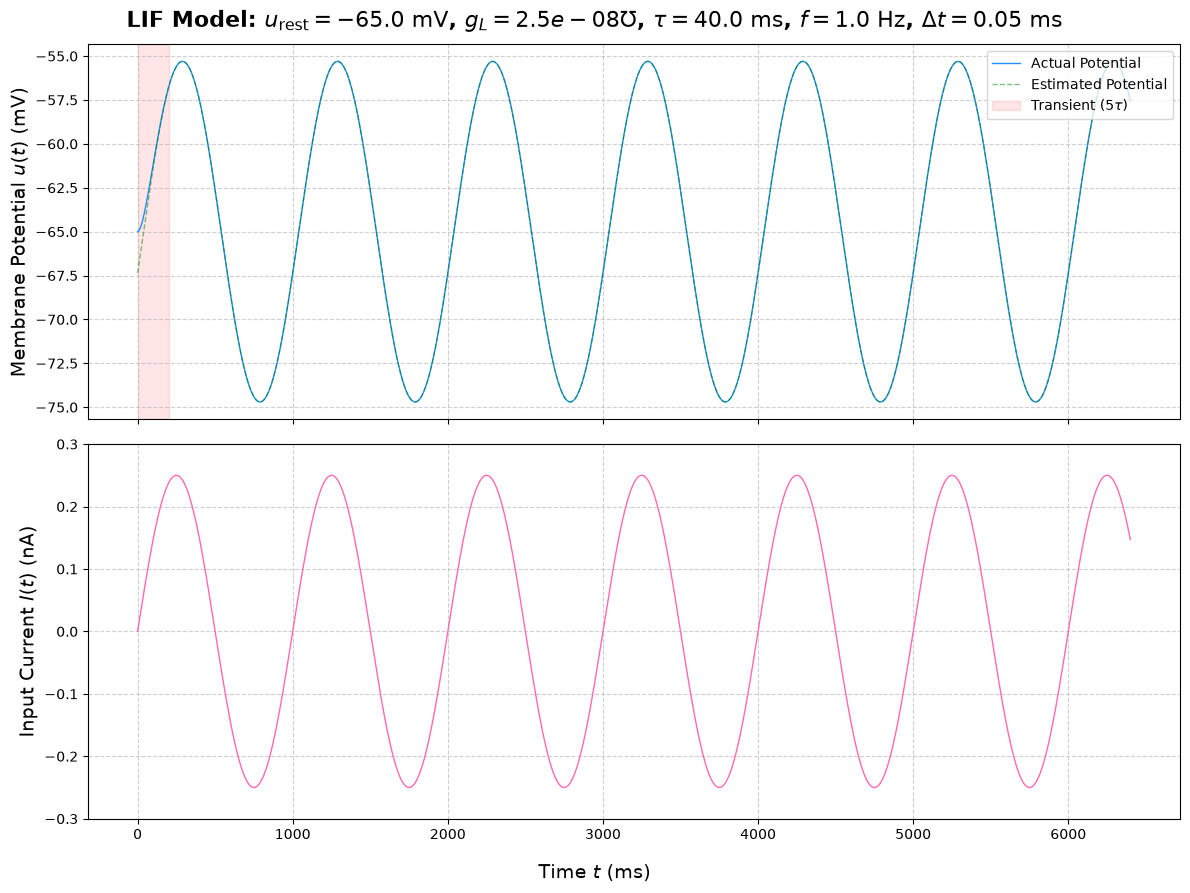

-0.06499981552028285 0.009405330460261006 -0.34648360653381755


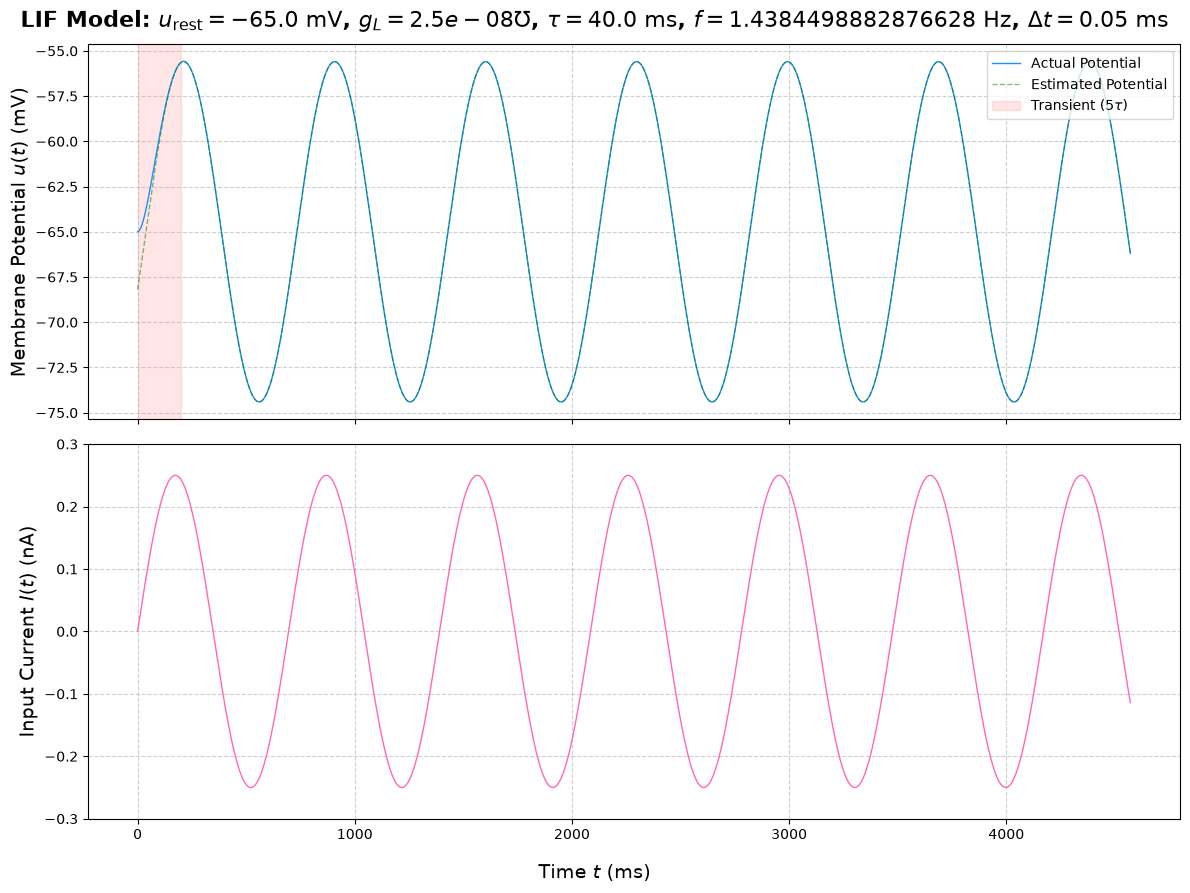

-0.06499966470141083 0.008873575021600494 -0.47901978073376533


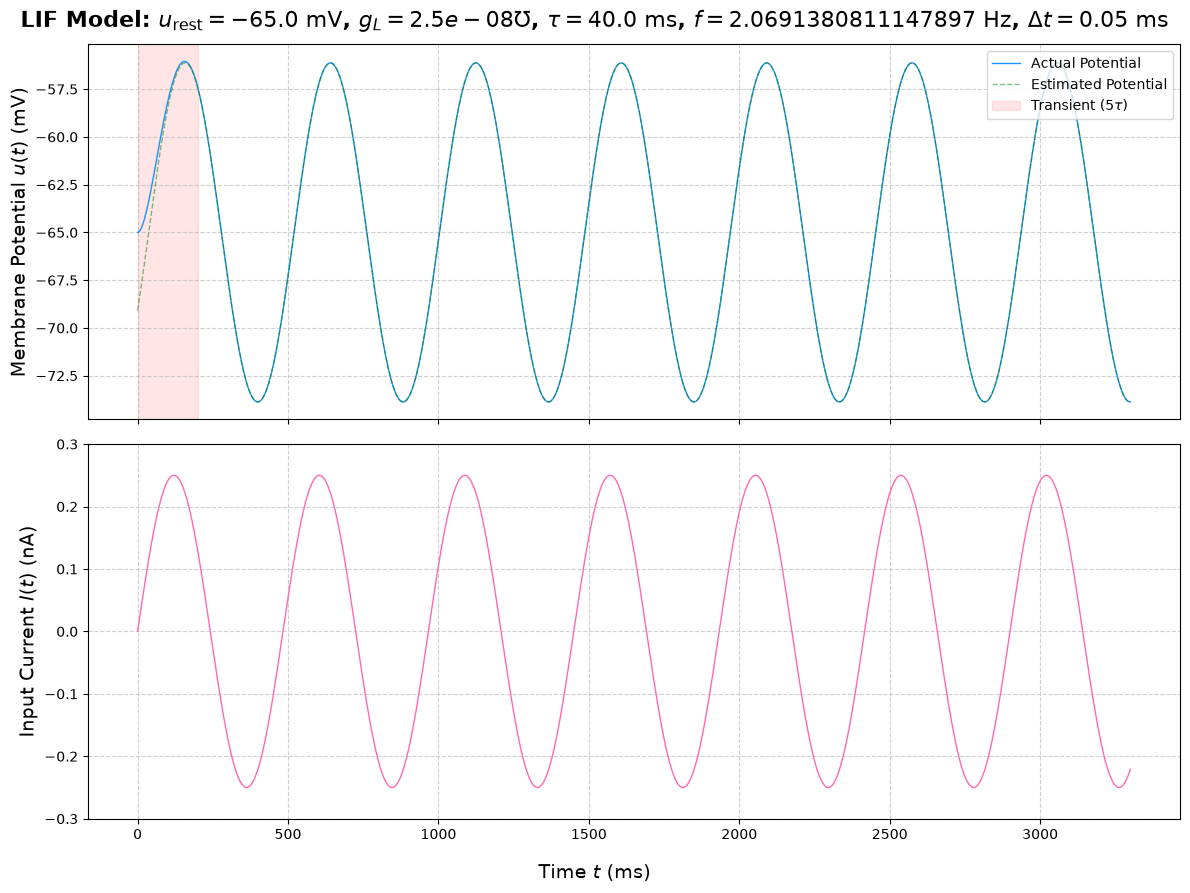

-0.06499943177424233 0.008008854178549109 -0.6415733301800762


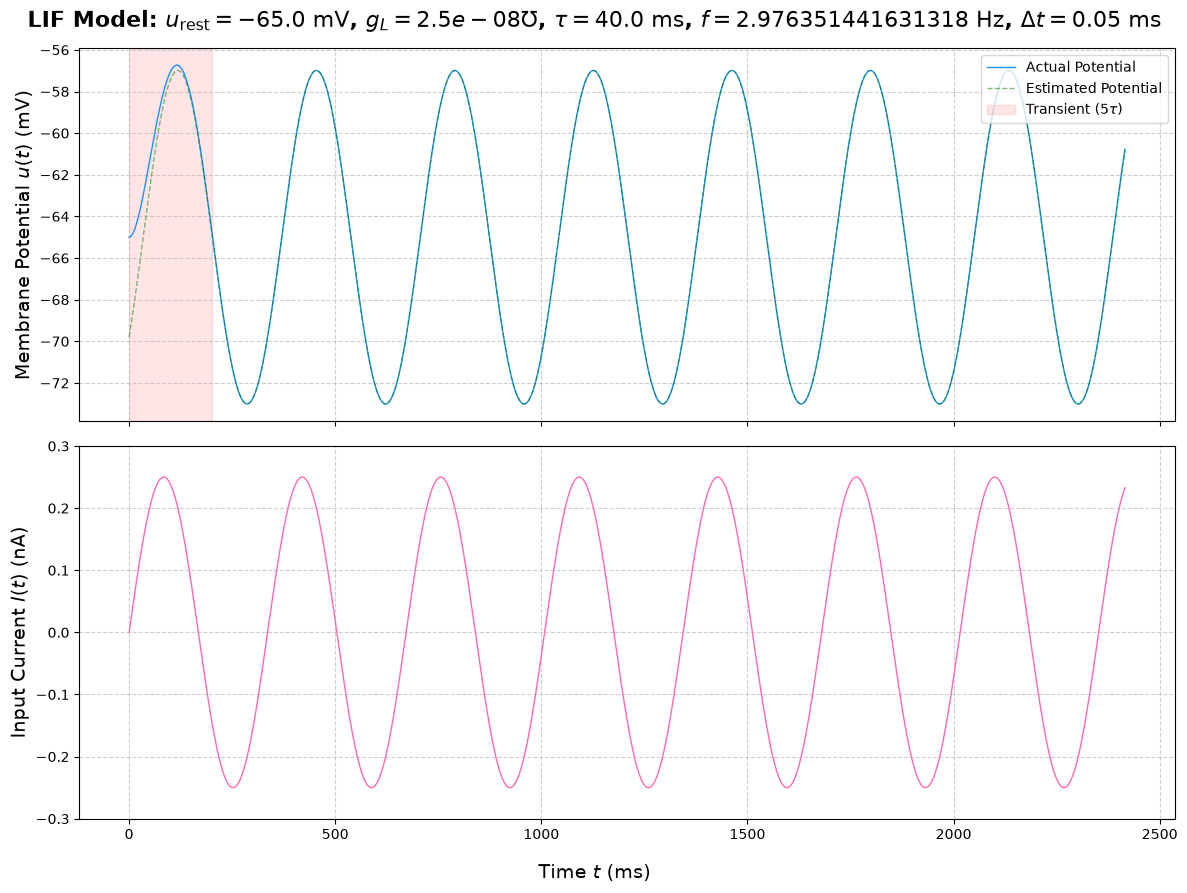

-0.06499915733722292 0.006808958377025991 -0.8209161528373334


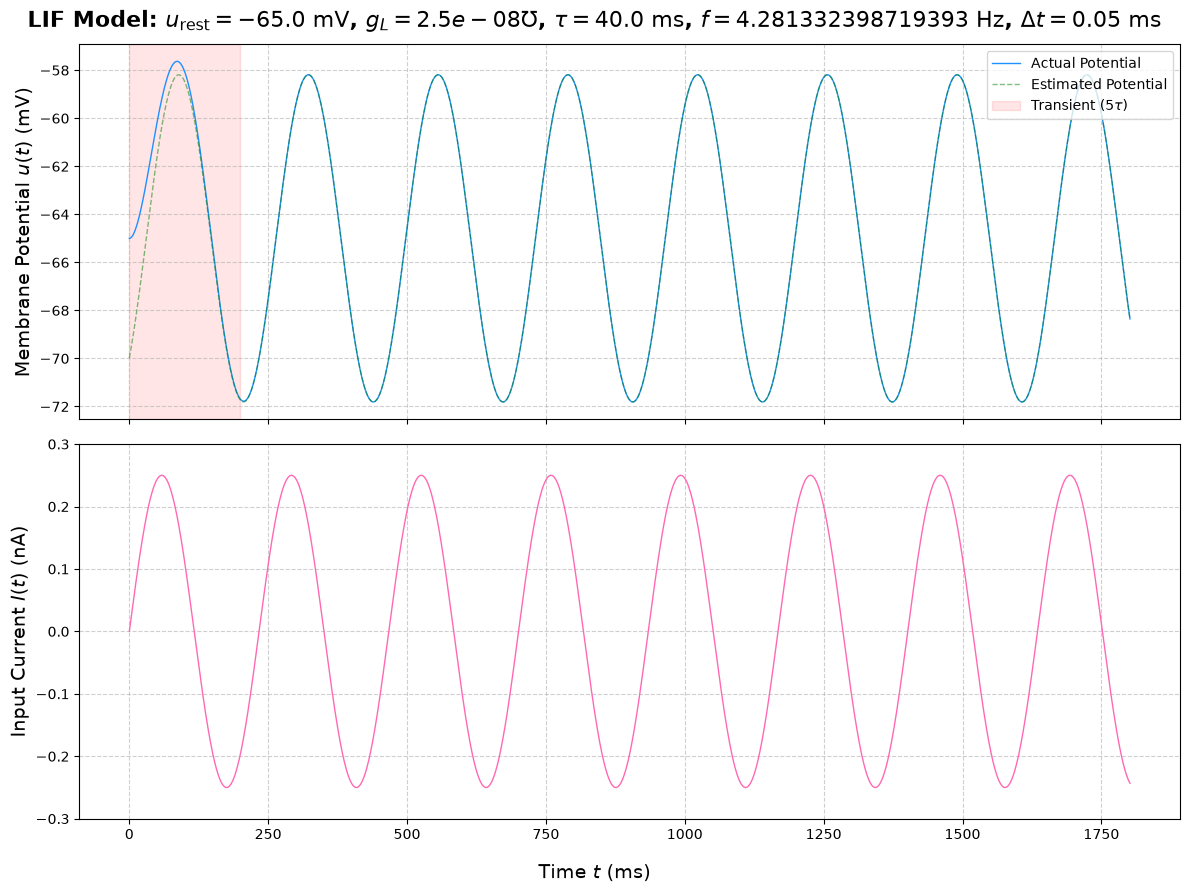

-0.06499898835946558 0.005430163060106756 -0.9959125802305422


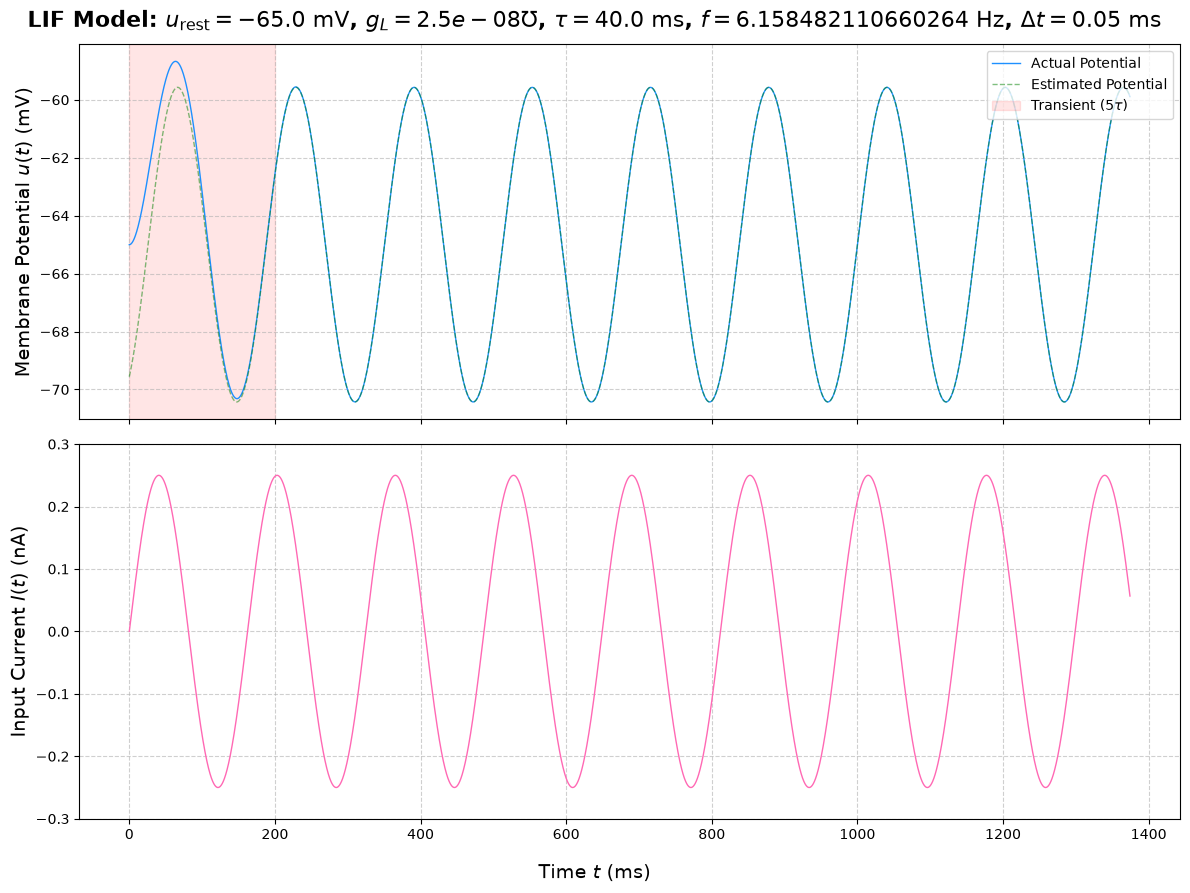

-0.06499886286822176 0.004098432194680644 -1.1470054917912595


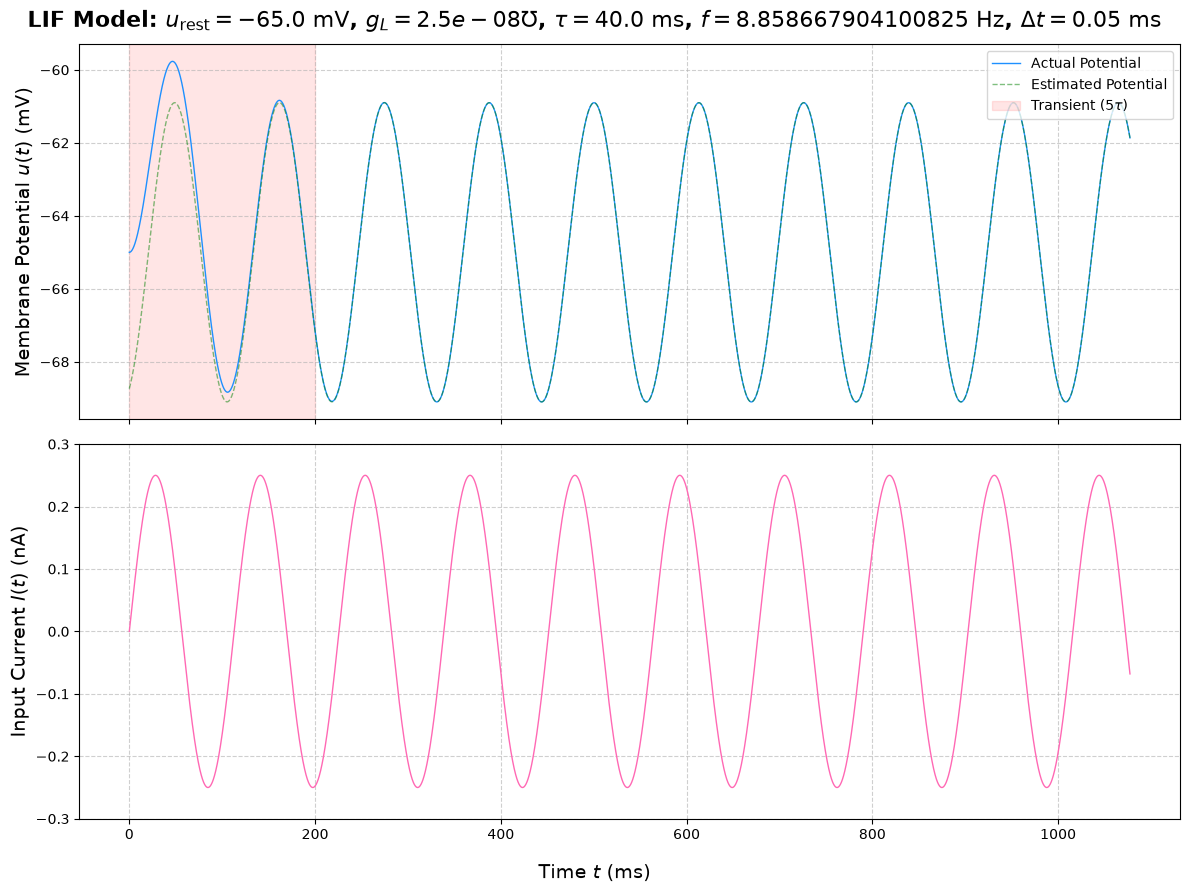

-0.0649988816694487 0.0029820896495978987 -1.2661608895218126


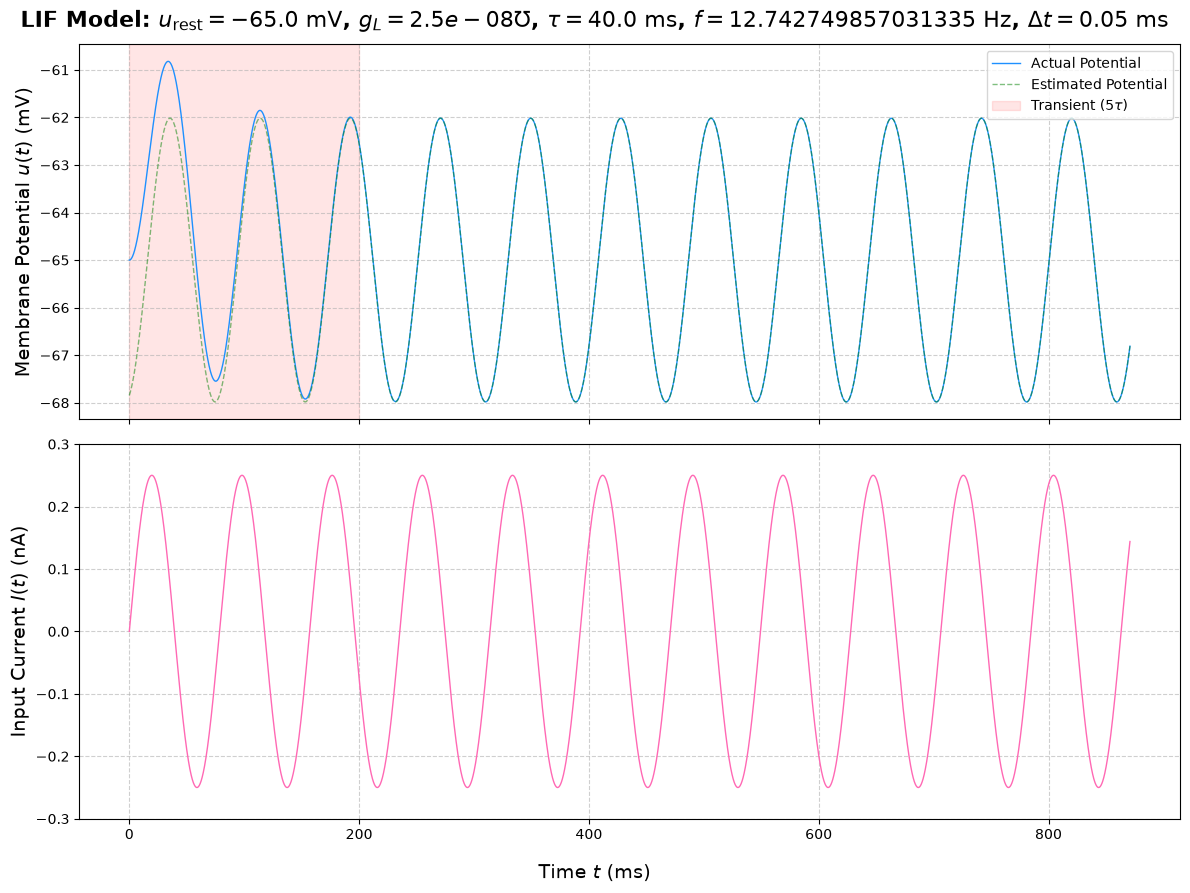

-0.06499895308682205 0.0021222469724815544 -1.354141888559857


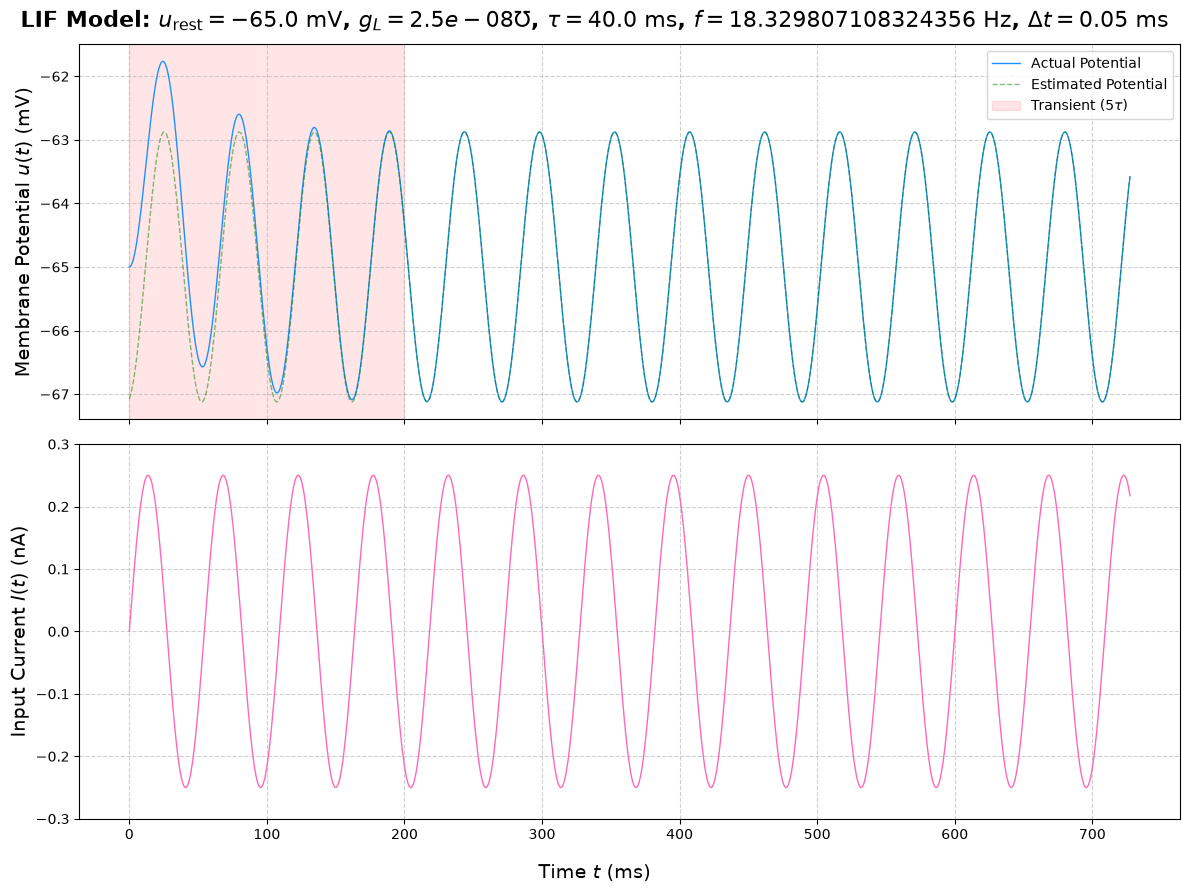

-0.06499907824392719 0.0014933208203542672 -1.416827940651923


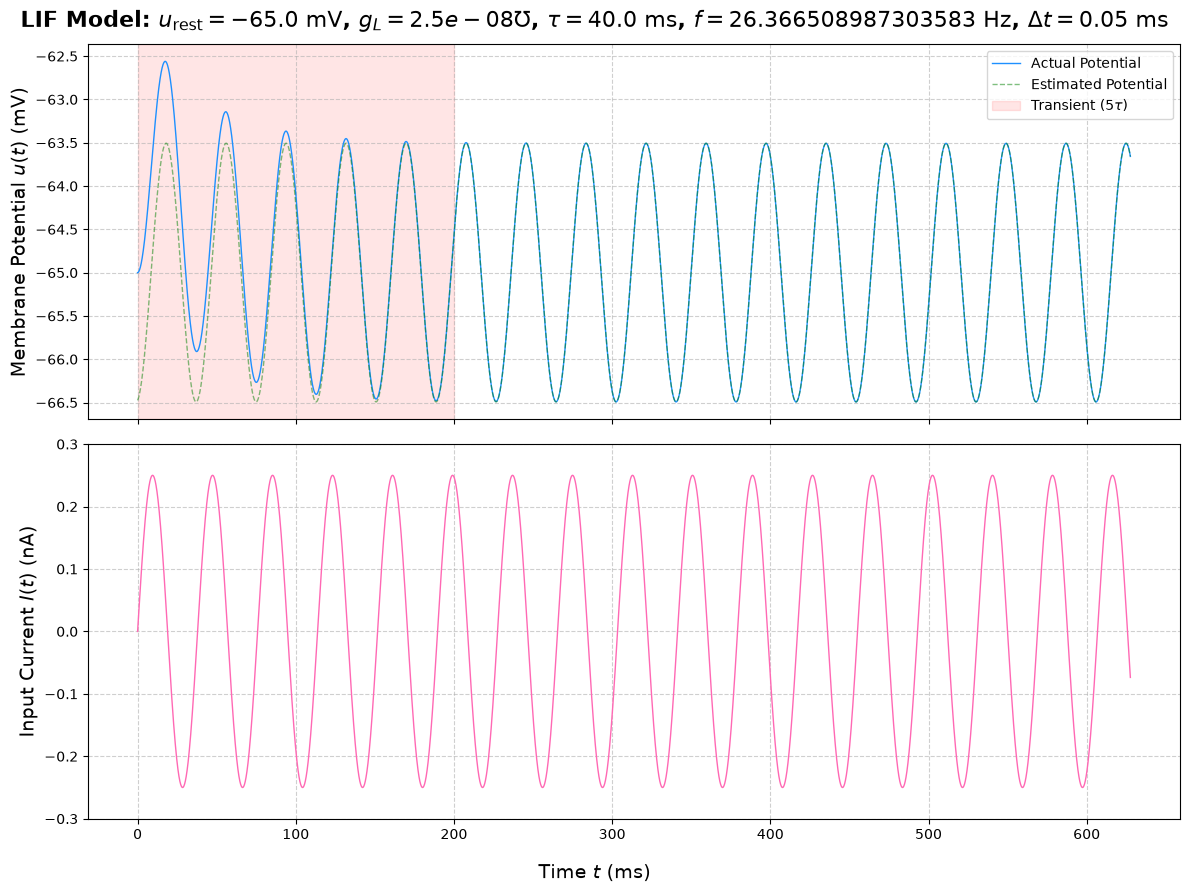

-0.0649992254047796 0.0010439583792464715 -1.4603610114034289


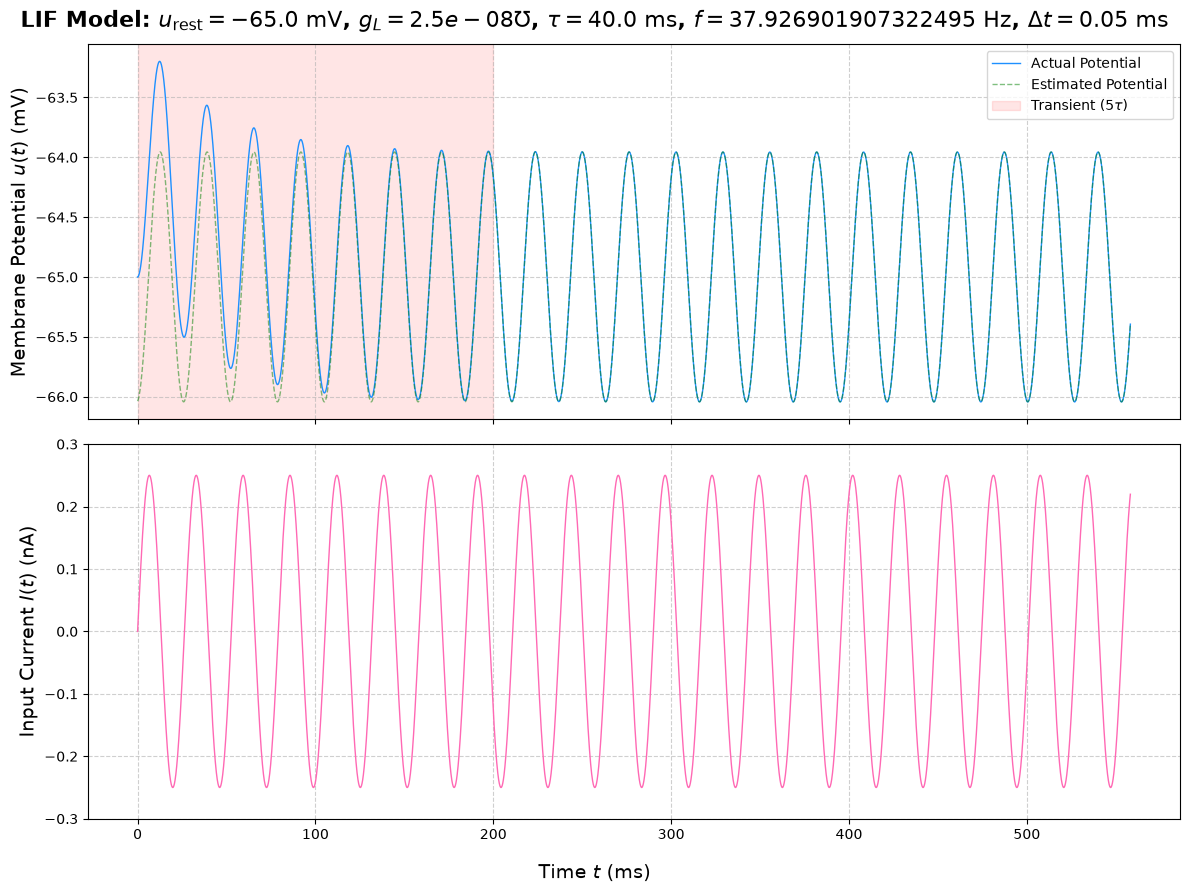

-0.06499937238097388 0.0007277979819022097 -1.4892787364467324


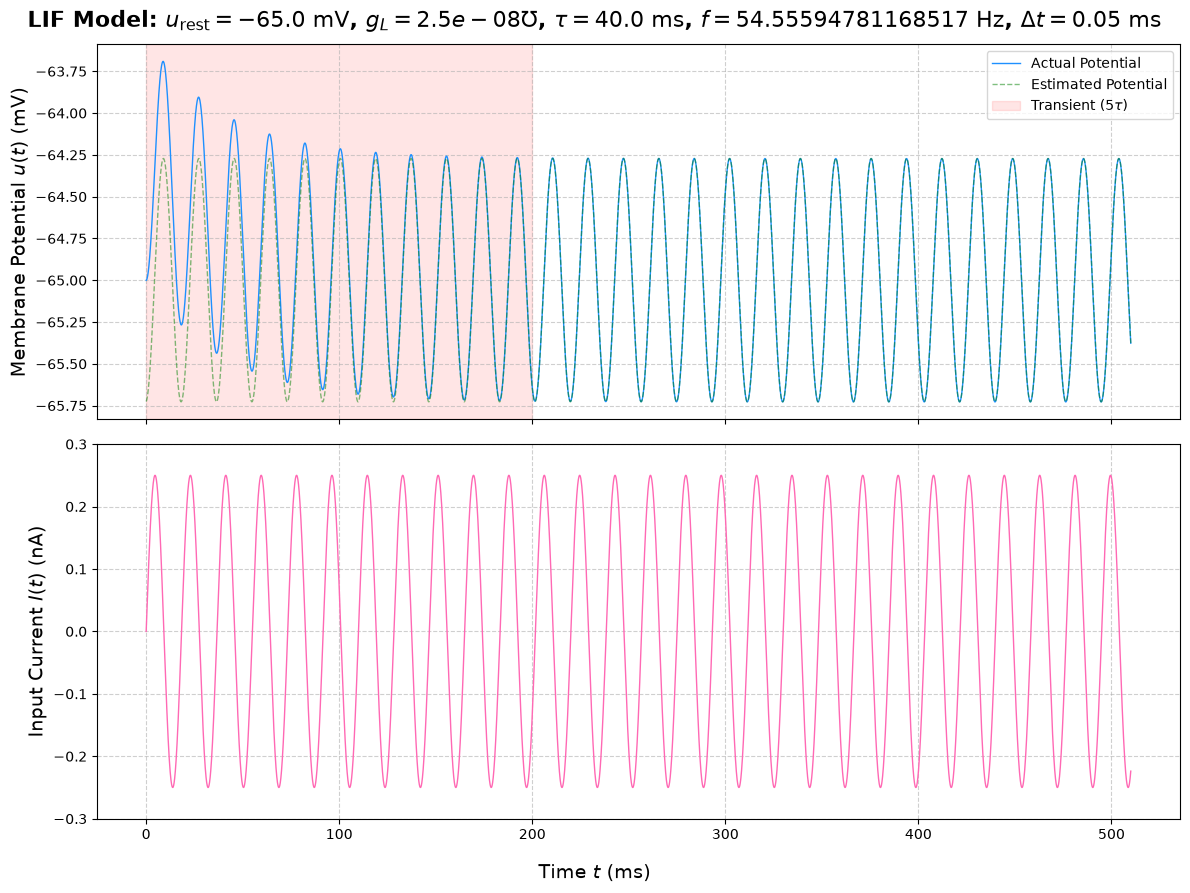

-0.06499951004510794 0.0005066598269816931 -1.5078201153244117


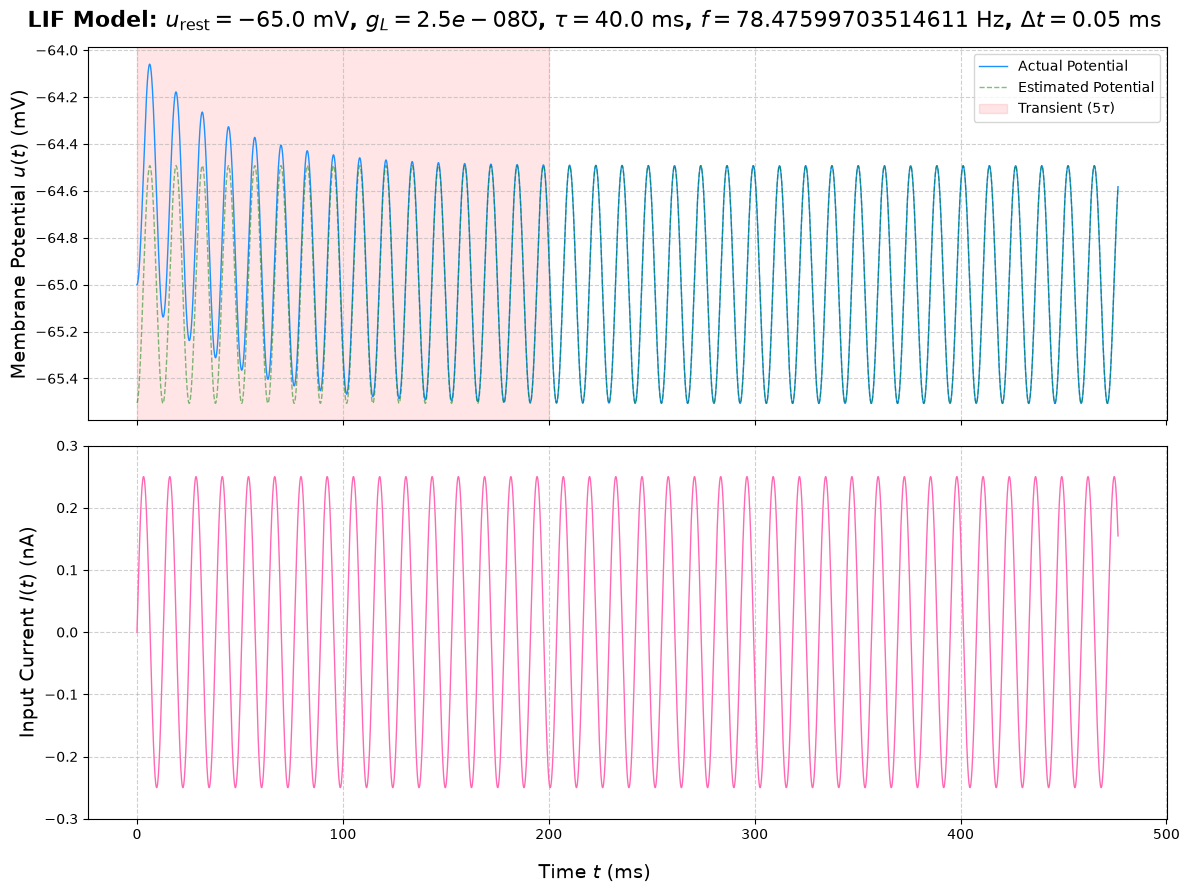

-0.06499962779930407 0.00035248769396098846 -1.5178626143625642


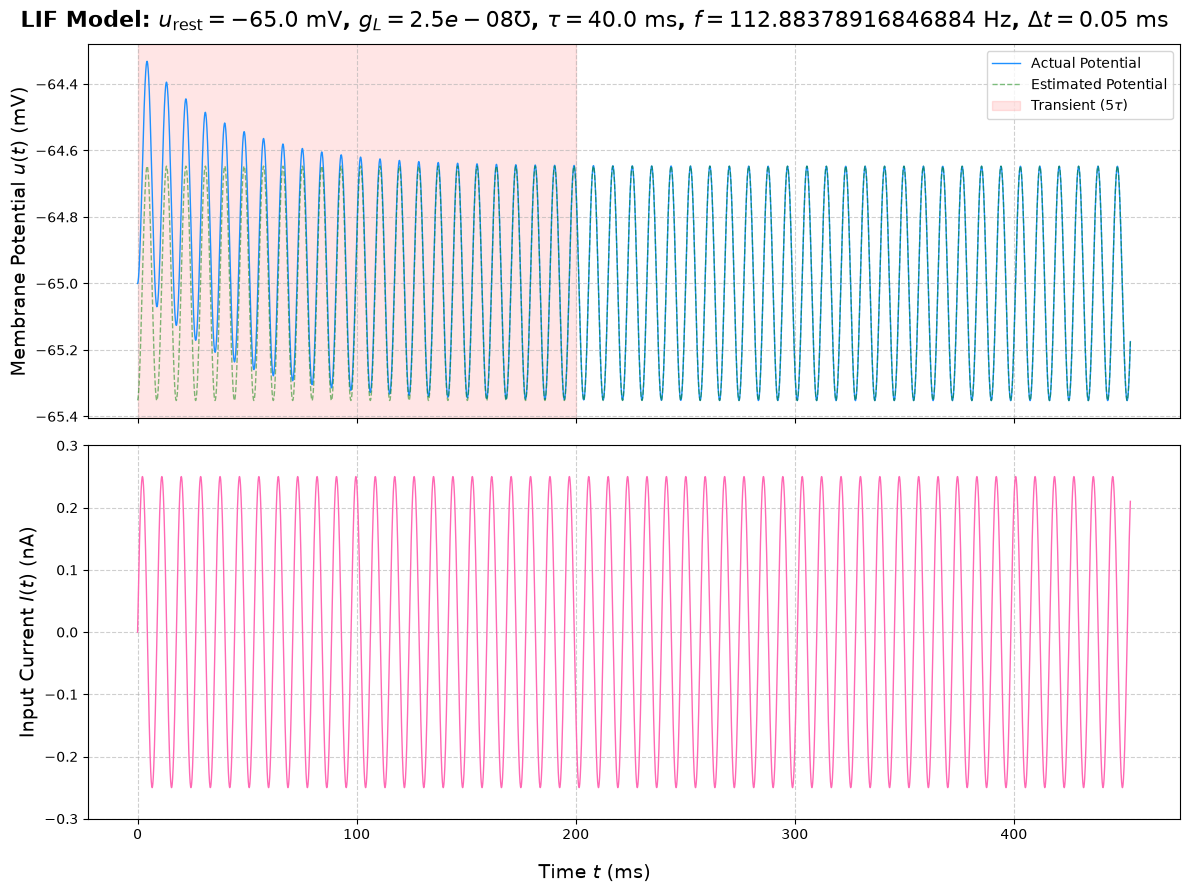

-0.06499972359798423 0.0002451452121332135 -1.5208179889064581


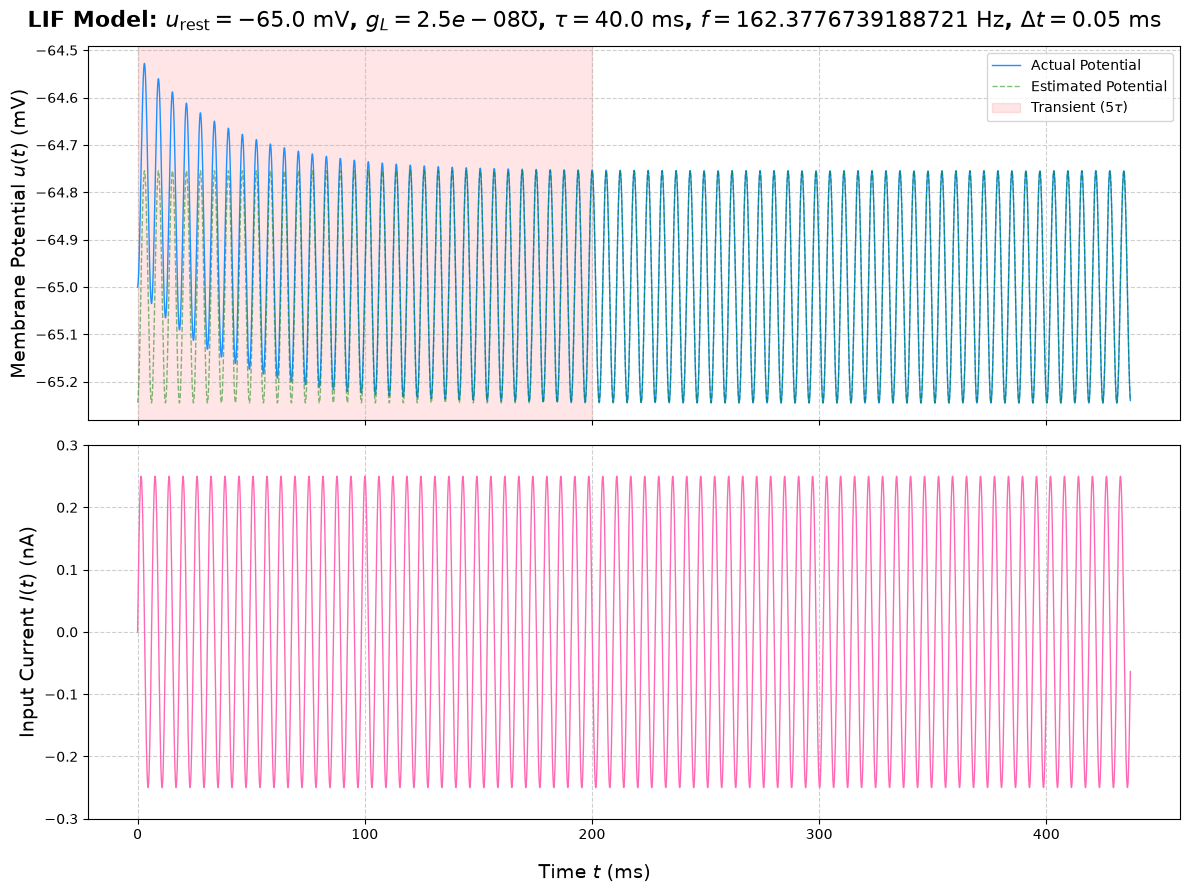

-0.06499979834847534 0.00017046362472523922 -1.517082276626003


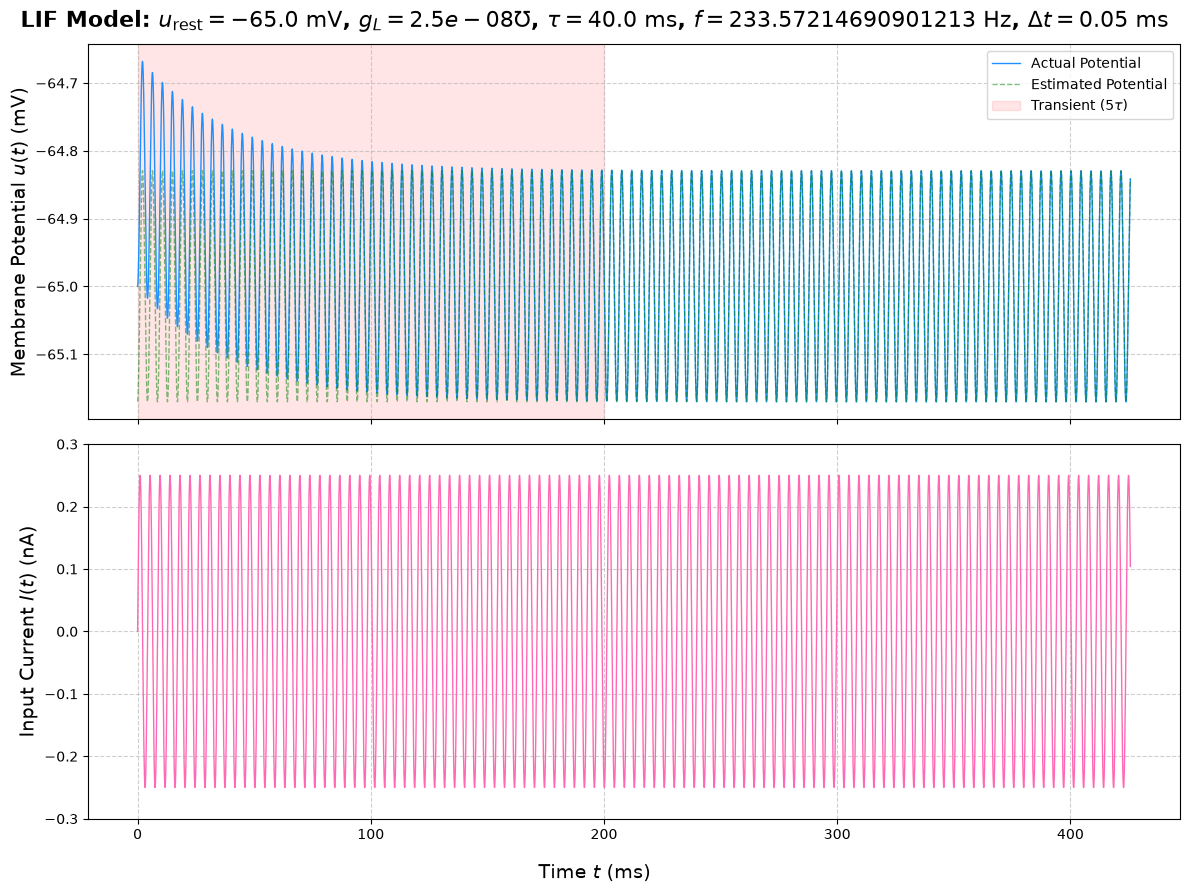

-0.06499985494609276 0.00011854907077360549 -1.5061812070365186


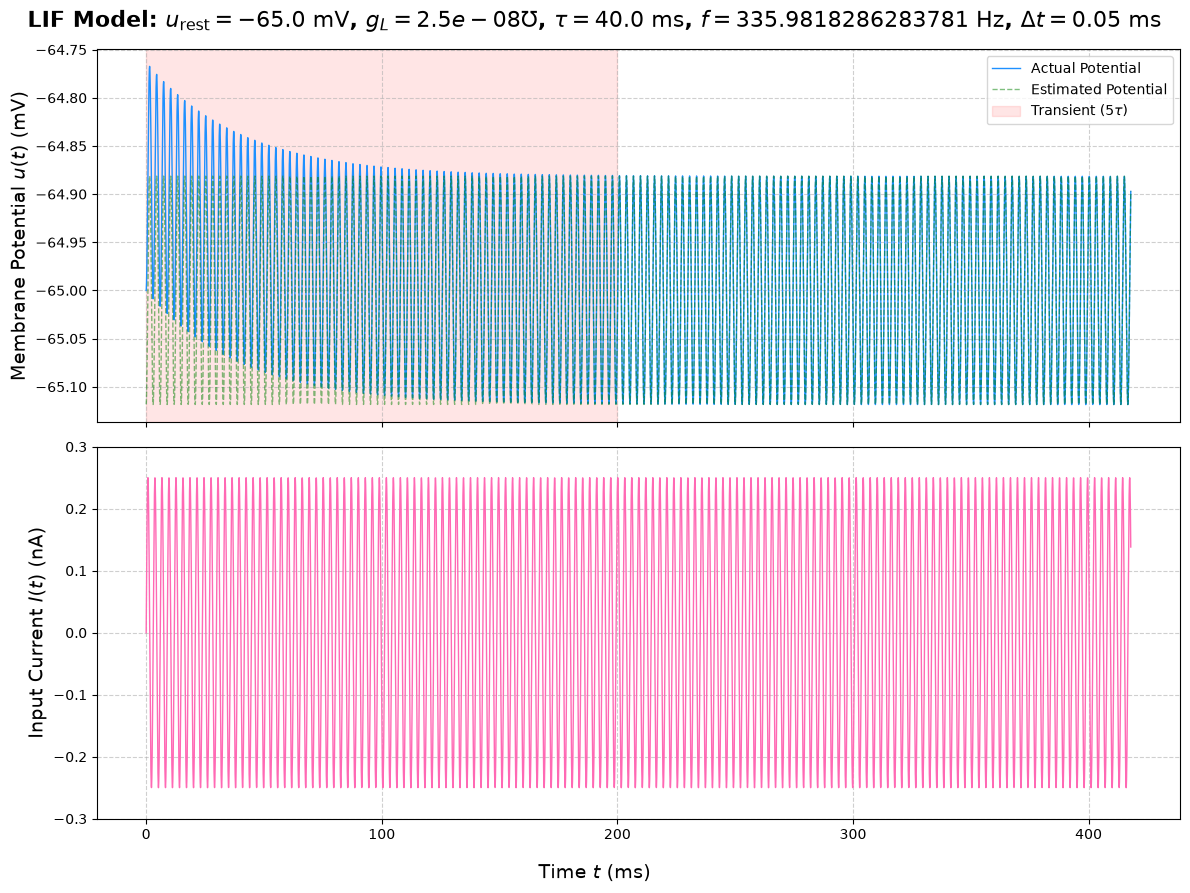

-0.06499989673286768 8.245524203186242e-05 -1.4866682006919012


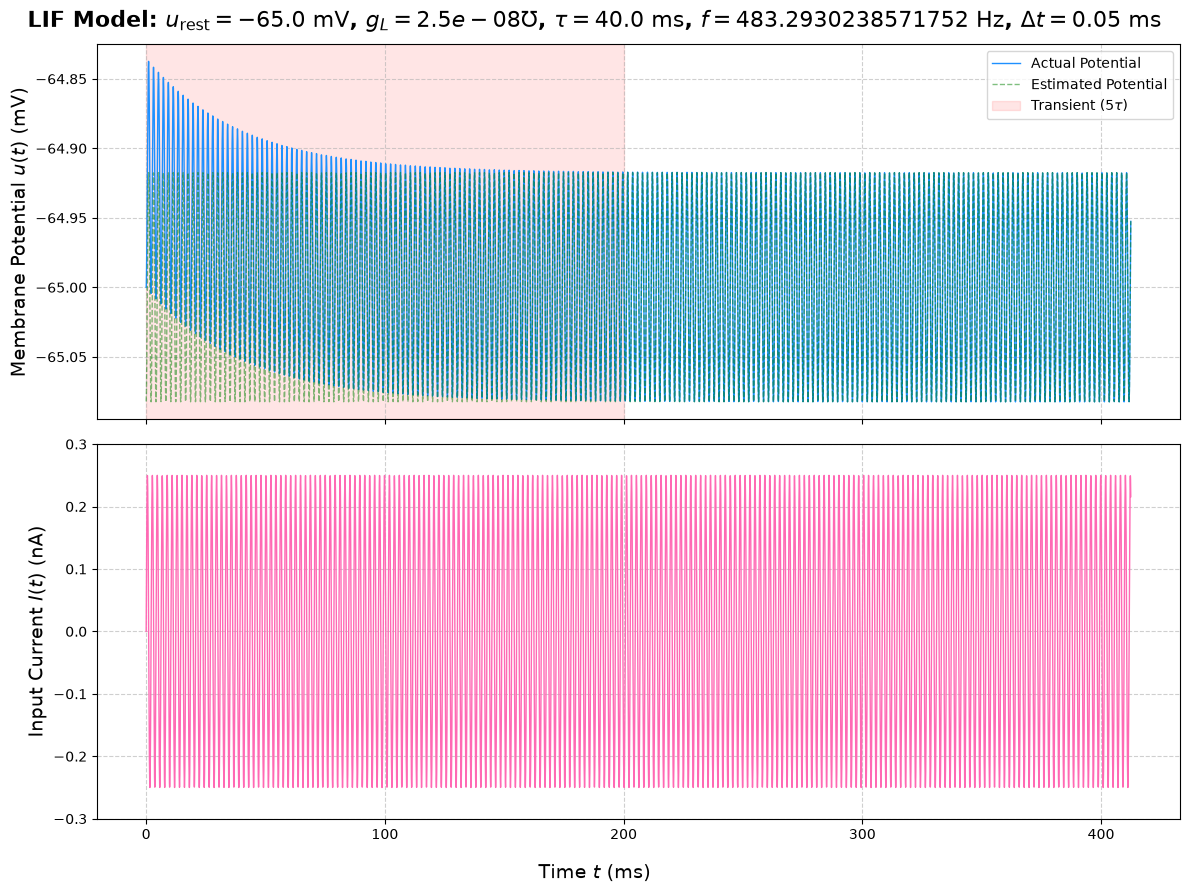

-0.06499992708429762 5.7383356148595366e-05 -1.4558790057420925


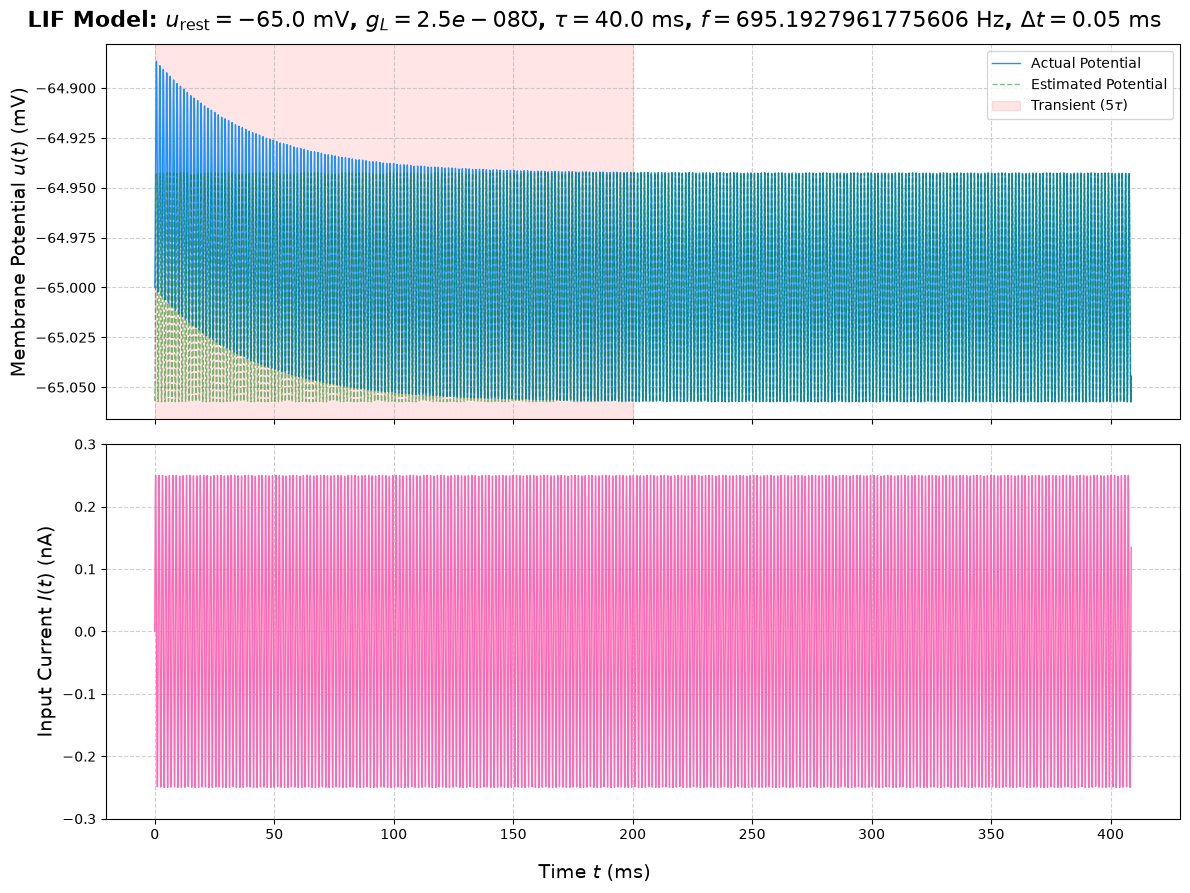

-0.06499994889521336 3.997763339358658e-05 -1.4097584314089764


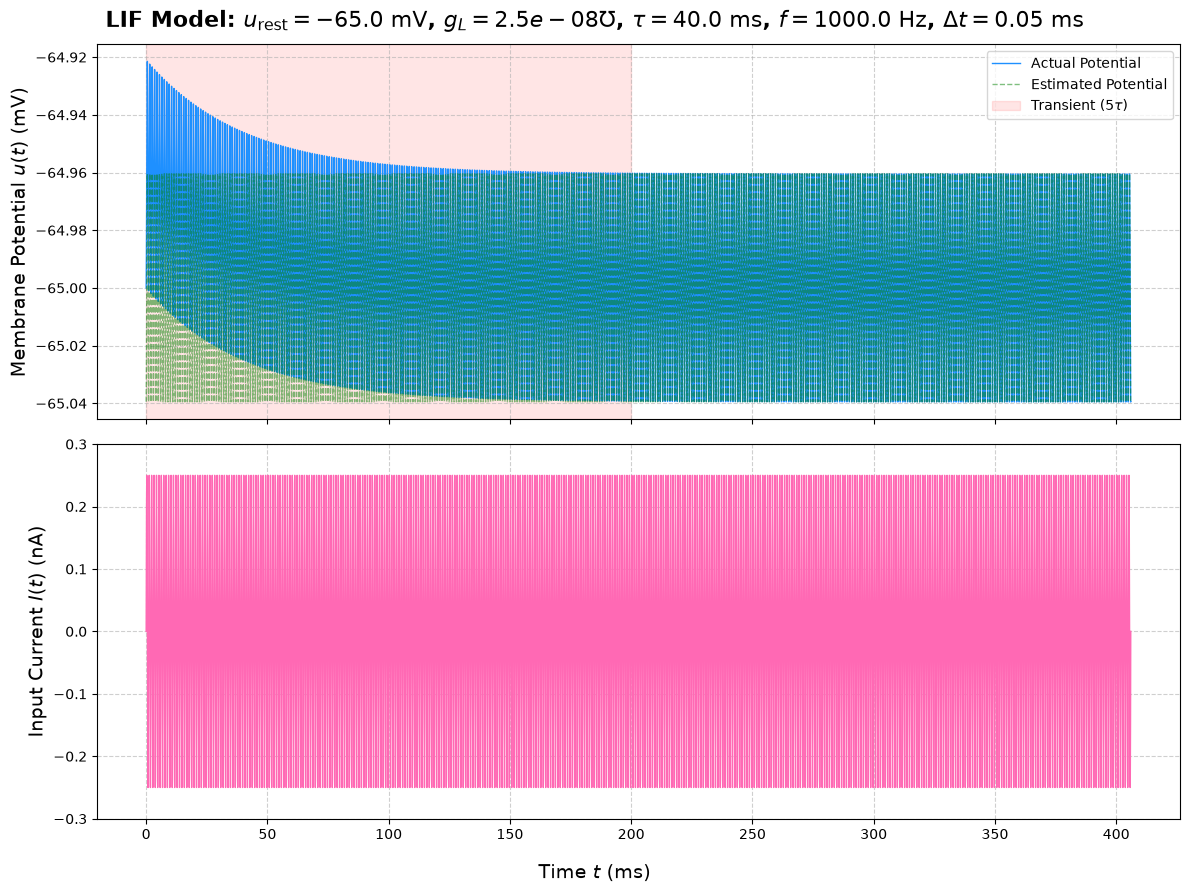

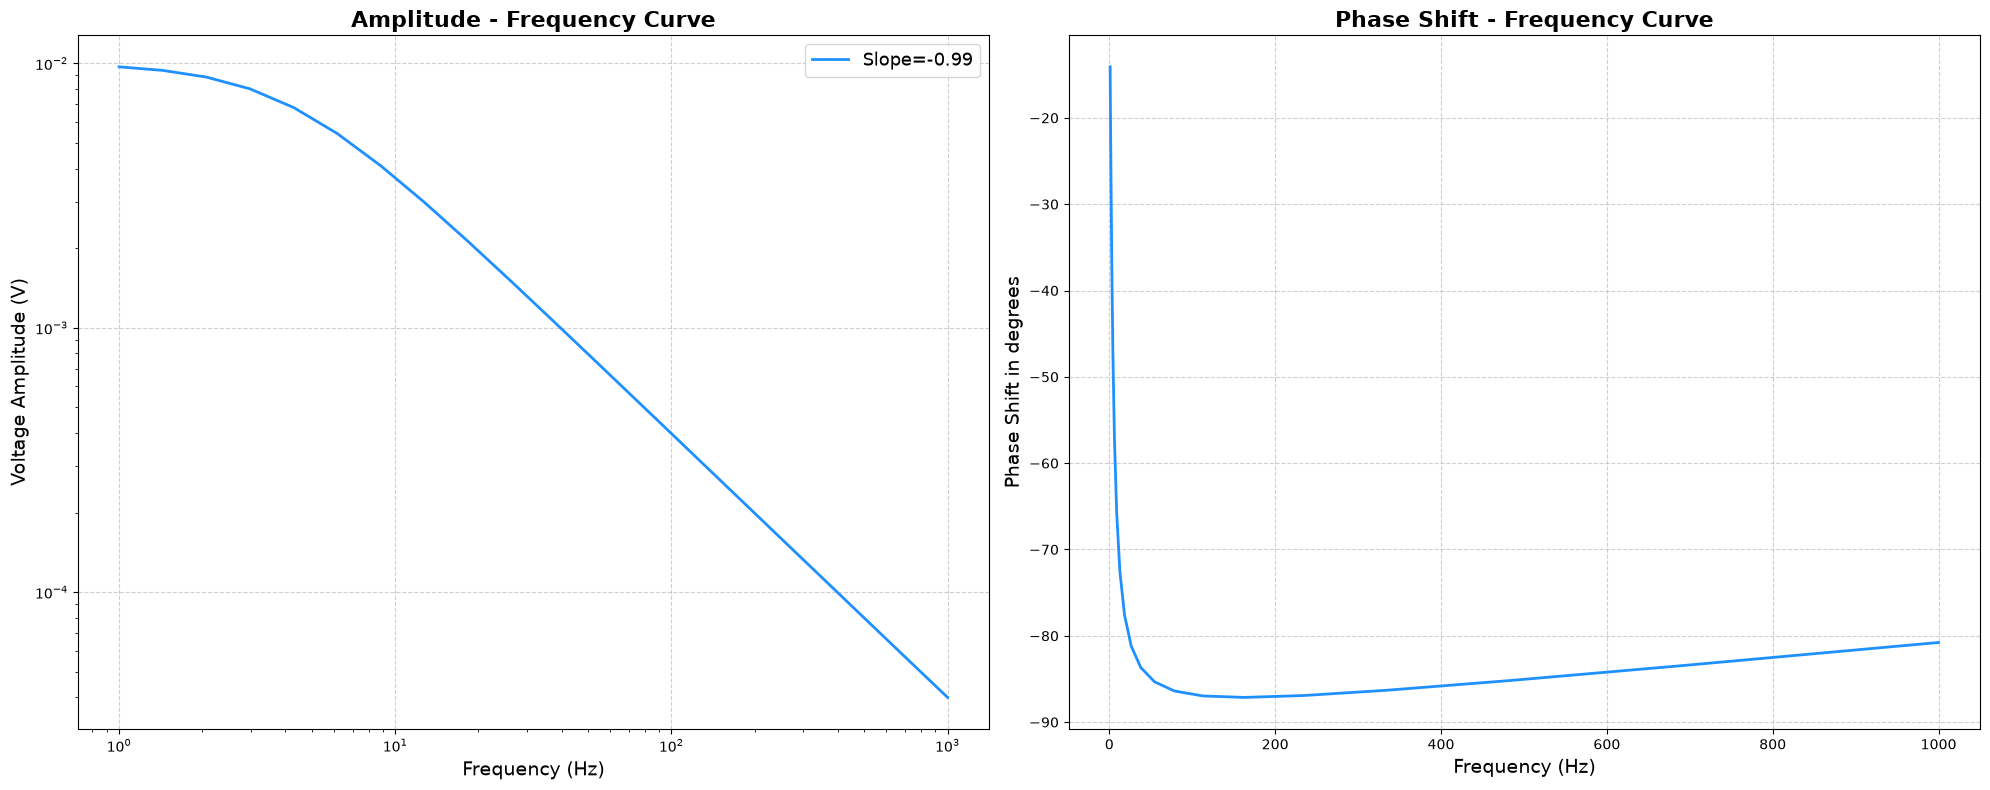

In [131]:
AMP = []
PHI = []
for f,t in zip(freqs, times):
    U, I, T = simulate_leaky_integrate_fire(u_rest, gL, tau, I_t, f, delta_t, 0, t)

    good_T = T[T > 5 * tau]
    good_U = U[T > 5 * tau]
    omega_t = 2*np.pi*f*good_T
    M = np.column_stack([np.sin(omega_t), np.cos(omega_t), np.ones_like(good_T)])
    (a, b, u_0), _, _, _ = np.linalg.lstsq(M, good_U)
    amp = np.sqrt(a**2 + b**2)
    phi = np.arctan2(b,a)
    AMP.append(amp)
    PHI.append(phi)
    print(u_0, amp, phi)
    plot_membrane_potential(U, I, T, f, u_0, amp, phi, f"./q2_sim/{f}.png")

# Convert lists to NumPy arrays for easy masking
AMP_arr = np.array(AMP)
# 1. Filter data between 10^1 (10 Hz) and 10^3 (1000 Hz)
mask = (freqs >= 1e1) & (freqs <= 1e3)
log_f = np.log10(freqs[mask])
log_amp = np.log10(AMP_arr[mask])

fig, ax = plt.subplots(1,2, figsize=(20, 8))
ax[0].plot(freqs, AMP, lw=2, c="dodgerblue", label=f"Slope={np.polyfit(log_f, log_amp, 1)[0]:.2f}")
ax[0].set_ylabel("Voltage Amplitude (V)", fontsize=14)
ax[0].set_xlabel("Frequency (Hz)", fontsize=14)
ax[0].set_title("Amplitude - Frequency Curve", fontsize=16, fontweight='bold')
ax[0].grid(True, linestyle="--", alpha=0.6)
ax[0].loglog()
ax[0].legend(fontsize=13, loc="upper right")

ax[1].plot(freqs, [phi * 180 / np.pi for phi in PHI], lw=2, c="dodgerblue")
ax[1].set_ylabel("Phase Shift in degrees", fontsize=14)
ax[1].set_xlabel("Frequency (Hz)", fontsize=14)
ax[1].set_title("Phase Shift - Frequency Curve", fontsize=16, fontweight='bold')
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
fig.savefig("./phase_amp.png", dpi=500)
plt.show(fig)


---